# Project 3 Milestone 5 — Angular Momentum Diagnostics

This notebook builds on the Project 3 distance-recovery output and computes angular-momentum diagnostics for candidate stars.

Main diagnostics:

- \(L_z\): vertical angular momentum, useful for separating prograde, retrograde, and low-rotation populations.
- \(L_\perp = \sqrt{L_x^2 + L_y^2}\): perpendicular angular momentum, useful for identifying high-inclination or halo-like orbital behavior.
- \(L_{tot} = \sqrt{L_x^2 + L_y^2 + L_z^2}\): total angular-momentum magnitude.

The goal is not yet full orbit integration. This milestone prepares angular-momentum evidence for later orbit-family interpretation.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import astropy.units as u
    from astropy.coordinates import SkyCoord, Galactocentric
except Exception as exc:
    raise ImportError(
        "This notebook requires astropy for coordinate transformation. "
        "Install with `pip install astropy` in the active environment if needed."
    ) from exc

warnings.filterwarnings("ignore")

# Robust repo-root detection.
# nbconvert may execute notebooks from `notebooks/`, while paths in this project
# are written relative to the repository root.
cwd = Path.cwd().resolve()
repo_candidates = [cwd, *cwd.parents]

REPO_ROOT = next(
    (
        p for p in repo_candidates
        if (p / "data/processed/project3_distance_recovered_candidates.csv").exists()
    ),
    None,
)

if REPO_ROOT is None:
    available = []
    for p in repo_candidates:
        data_dir = p / "data/processed"
        if data_dir.exists():
            available.extend(str(x) for x in data_dir.glob("*distance*"))
    raise FileNotFoundError(
        "Could not locate repository root containing "
        "data/processed/project3_distance_recovered_candidates.csv. "
        f"Current working directory: {cwd}. "
        f"Distance-like files found while searching upward: {available}"
    )

INPUT_PATH = REPO_ROOT / "data/processed/project3_distance_recovered_candidates.csv"
OUTPUT_PATH = REPO_ROOT / "data/processed/project3_angular_momentum_candidates.csv"
SUMMARY_PATH = REPO_ROOT / "data/processed/project3_angular_momentum_summary.csv"
FIG_DIR = REPO_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Using input: {INPUT_PATH}")

df = pd.read_csv(INPUT_PATH)
print(df.shape)
df.head()


Repository root: /Users/liors/Documents/gaia-lamost-galactic-archaeology
Using input: /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/project3_distance_recovered_candidates.csv
(27, 68)


,source_id,ra,dec,parallax,pmra,pmdec,radial_velocity,bp_rp,absolute_g_mag,feh,...,rv,parallax_mas_recovered,parallax_error_mas_recovered,distance_existing_recovered,distance_pc_from_parallax,distance_kpc_from_parallax,parallax_snr_recovered,distance_recovery_source,distance_quality_flag,angular_momentum_ready_basic
0,3077457042404665088,NaN,NaN,NaN,NaN,NaN,NaN,1.252923,1.686704,-0.599,...,270.86,NaN,NaN,1740.005754,NaN,NaN,NaN,gaia_lamost_larger_velocity_features.csv,missing_parallax,False
1,3089847099636770560,NaN,NaN,NaN,NaN,NaN,NaN,0.618819,3.726077,-2.213,...,-11.29,NaN,NaN,1569.487021,NaN,NaN,NaN,gaia_lamost_larger_velocity_features.csv,missing_parallax,False
2,3089944573918027648,NaN,NaN,NaN,NaN,NaN,NaN,0.984529,1.568062,-1.472,...,385.54,NaN,NaN,1658.864371,NaN,NaN,NaN,gaia_lamost_larger_velocity_features.csv,missing_parallax,False
3,3089534353001157632,NaN,NaN,NaN,NaN,NaN,NaN,1.041462,0.871324,-1.539,...,-43.26,NaN,NaN,2179.762224,NaN,NaN,NaN,gaia_lamost_larger_velocity_features.csv,missing_parallax,False
4,3084095863550902528,NaN,NaN,NaN,NaN,NaN,NaN,0.728496,2.774414,-1.723,...,9.04,NaN,NaN,2967.169602,NaN,NaN,NaN,gaia_lamost_larger_velocity_features.csv,missing_parallax,False


## 1. Column detection

The upstream files may contain slightly different column names depending on the milestone.  
This section detects the required astrometric, radial-velocity, metallicity, and distance columns robustly.


In [2]:
def find_col(frame, candidates, required=True, prefer_non_null=True):
    """Find a column by candidate names, preferring columns with usable values.

    Some upstream milestone tables keep original columns that are entirely empty
    while storing recovered values in suffixed columns such as `ra_gaia` or
    `pmra_recovered`. This helper avoids selecting an all-null column when a
    later candidate contains actual data.
    """
    cols_lower = {c.lower(): c for c in frame.columns}
    matches = [cols_lower[cand.lower()] for cand in candidates if cand.lower() in cols_lower]

    if matches and prefer_non_null:
        non_null_matches = []
        for col in matches:
            s = pd.to_numeric(frame[col], errors="coerce") if frame[col].dtype == object else frame[col]
            non_null_matches.append((int(pd.Series(s).replace([np.inf, -np.inf], np.nan).notna().sum()), col))
        non_null_matches = sorted(non_null_matches, reverse=True)
        if non_null_matches[0][0] > 0:
            return non_null_matches[0][1]

    if matches:
        return matches[0]

    if required:
        raise KeyError(f"Could not find any of these columns: {candidates}")
    return None


ra_col = find_col(df, ["ra_gaia", "ra", "ra_deg", "source_ra", "ra_lamost"])
dec_col = find_col(df, ["dec_gaia", "dec", "dec_deg", "source_dec", "dec_lamost"])
pmra_col = find_col(df, ["pmra_recovered", "pmra", "pmra_masyr", "pmra_mas_per_year"])
pmdec_col = find_col(df, ["pmdec_recovered", "pmdec", "pmdec_masyr", "pmdec_mas_per_year"])

rv_col = find_col(df, [
    "rv", "radial_velocity", "radial_velocity_kms",
    "lamost_rv", "rv_lamost", "vr"
])

feh_col = find_col(df, ["feh", "fe_h", "[fe/h]", "mh"], required=False)

distance_col = find_col(df, [
    "distance_kpc_used",
    "distance_kpc",
    "recovered_distance_kpc",
    "distance_recovered_kpc",
    "adopted_distance_kpc",
    "distance_pc",
    "recovered_distance_pc",
    "distance_recovered_pc",
    "adopted_distance_pc",
    "distance_existing_recovered",
])

source_id_col = find_col(df, ["source_id", "gaia_source_id"], required=False)

detected = {
    "ra": ra_col,
    "dec": dec_col,
    "pmra": pmra_col,
    "pmdec": pmdec_col,
    "radial_velocity": rv_col,
    "metallicity": feh_col,
    "distance": distance_col,
    "source_id": source_id_col,
}
detected


{'ra': 'ra_lamost',
 'dec': 'dec_lamost',
 'pmra': 'pmra_recovered',
 'pmdec': 'pmdec_recovered',
 'radial_velocity': 'rv',
 'metallicity': 'feh',
 'distance': 'distance_pc',
 'source_id': 'source_id'}

In [3]:
work = df.copy()

# Normalize distance to kpc.
if distance_col.lower().endswith("_pc") or ("pc" in distance_col.lower() and "kpc" not in distance_col.lower()):
    work["distance_for_l_kpc"] = pd.to_numeric(work[distance_col], errors="coerce") / 1000.0
else:
    work["distance_for_l_kpc"] = pd.to_numeric(work[distance_col], errors="coerce")

# Convert available astrometric columns.
for col in [ra_col, dec_col, pmra_col, pmdec_col, rv_col]:
    if col is not None:
        work[col] = pd.to_numeric(work[col], errors="coerce")

# Project 3 upstream milestones may already contain Galactocentric velocity columns.
# For angular momentum, we need position + velocity. If existing Galactocentric
# velocities are available, do not require raw pm/radial-velocity completeness here.
vx_existing_col = find_col(work, ["galcen_vx_kms", "galcen_vx", "vx_galcen", "vx"], required=False)
vy_existing_col = find_col(work, ["galcen_vy_kms", "galcen_vy", "vy_galcen", "vy"], required=False)
vz_existing_col = find_col(work, ["galcen_vz_kms", "galcen_vz", "vz_galcen", "vz"], required=False)

existing_velocity_cols = [vx_existing_col, vy_existing_col, vz_existing_col]

has_existing_velocity = all(c is not None for c in existing_velocity_cols)
if has_existing_velocity:
    for col in existing_velocity_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")
    has_existing_velocity = all(
        work[col].replace([np.inf, -np.inf], np.nan).notna().sum() > 0
        for col in existing_velocity_cols
    )

if has_existing_velocity:
    required_cols = [ra_col, dec_col, "distance_for_l_kpc", *existing_velocity_cols]
    velocity_input_mode = "existing_galactocentric_velocity_columns"
else:
    required_cols = [ra_col, dec_col, pmra_col, pmdec_col, rv_col, "distance_for_l_kpc"]
    velocity_input_mode = "raw_astrometry_plus_radial_velocity"

required_cols = [c for c in required_cols if c is not None]
valid = work[required_cols].replace([np.inf, -np.inf], np.nan).notna().all(axis=1)
valid &= work["distance_for_l_kpc"] > 0

print("Input rows:", len(work))
print("Velocity input mode:", velocity_input_mode)
print("Required columns:", required_cols)
print("Rows with valid angular-momentum inputs:", int(valid.sum()))
print("Rows excluded:", int((~valid).sum()))

am = work.loc[valid].copy()
am.head()


Input rows: 27
Velocity input mode: raw_astrometry_plus_radial_velocity
Required columns: ['ra_lamost', 'dec_lamost', 'pmra_recovered', 'pmdec_recovered', 'rv', 'distance_for_l_kpc']
Rows with valid angular-momentum inputs: 27
Rows excluded: 0


,source_id,ra,dec,parallax,pmra,pmdec,radial_velocity,bp_rp,absolute_g_mag,feh,...,parallax_mas_recovered,parallax_error_mas_recovered,distance_existing_recovered,distance_pc_from_parallax,distance_kpc_from_parallax,parallax_snr_recovered,distance_recovery_source,distance_quality_flag,angular_momentum_ready_basic,distance_for_l_kpc
0,3077457042404665088,NaN,NaN,NaN,NaN,NaN,NaN,1.252923,1.686704,-0.599,...,NaN,NaN,1740.005754,NaN,NaN,NaN,gaia_lamost_larger_velocity_features.csv,missing_parallax,False,1.740006
1,3089847099636770560,NaN,NaN,NaN,NaN,NaN,NaN,0.618819,3.726077,-2.213,...,NaN,NaN,1569.487021,NaN,NaN,NaN,gaia_lamost_larger_velocity_features.csv,missing_parallax,False,1.569487
2,3089944573918027648,NaN,NaN,NaN,NaN,NaN,NaN,0.984529,1.568062,-1.472,...,NaN,NaN,1658.864371,NaN,NaN,NaN,gaia_lamost_larger_velocity_features.csv,missing_parallax,False,1.658864
3,3089534353001157632,NaN,NaN,NaN,NaN,NaN,NaN,1.041462,0.871324,-1.539,...,NaN,NaN,2179.762224,NaN,NaN,NaN,gaia_lamost_larger_velocity_features.csv,missing_parallax,False,2.179762
4,3084095863550902528,NaN,NaN,NaN,NaN,NaN,NaN,0.728496,2.774414,-1.723,...,NaN,NaN,2967.169602,NaN,NaN,NaN,gaia_lamost_larger_velocity_features.csv,missing_parallax,False,2.967170


## 2. Galactocentric phase-space transformation

We transform sky coordinates, proper motions, radial velocities, and recovered distances into Galactocentric Cartesian positions and velocities.

Astropy's default Galactocentric frame is used for reproducibility at this stage.  
The exact solar parameter choice should be documented and can be revisited during final scientific interpretation.


In [4]:
# Position transform from recovered distance.
# Velocity is taken from existing Galactocentric velocity columns when available,
# because upstream Project 3 milestones already prepared these velocity diagnostics.
coord_pos = SkyCoord(
    ra=am[ra_col].to_numpy() * u.deg,
    dec=am[dec_col].to_numpy() * u.deg,
    distance=am["distance_for_l_kpc"].to_numpy() * u.kpc,
    frame="icrs",
)

galcen_frame = Galactocentric()
galcen_pos = coord_pos.transform_to(galcen_frame)
cart = galcen_pos.cartesian

am["galcen_x_kpc"] = cart.x.to_value(u.kpc)
am["galcen_y_kpc"] = cart.y.to_value(u.kpc)
am["galcen_z_kpc"] = cart.z.to_value(u.kpc)

vx_existing_col = find_col(am, ["galcen_vx_kms", "galcen_vx", "vx_galcen", "vx"], required=False)
vy_existing_col = find_col(am, ["galcen_vy_kms", "galcen_vy", "vy_galcen", "vy"], required=False)
vz_existing_col = find_col(am, ["galcen_vz_kms", "galcen_vz", "vz_galcen", "vz"], required=False)

existing_velocity_available = all(c is not None for c in [vx_existing_col, vy_existing_col, vz_existing_col])
if existing_velocity_available:
    for col in [vx_existing_col, vy_existing_col, vz_existing_col]:
        am[col] = pd.to_numeric(am[col], errors="coerce")
    existing_velocity_available = all(
        am[col].replace([np.inf, -np.inf], np.nan).notna().sum() > 0
        for col in [vx_existing_col, vy_existing_col, vz_existing_col]
    )

if existing_velocity_available:
    am["galcen_vx_kms"] = pd.to_numeric(am[vx_existing_col], errors="coerce")
    am["galcen_vy_kms"] = pd.to_numeric(am[vy_existing_col], errors="coerce")
    am["galcen_vz_kms"] = pd.to_numeric(am[vz_existing_col], errors="coerce")
    velocity_source = {
        "galcen_vx_kms": vx_existing_col,
        "galcen_vy_kms": vy_existing_col,
        "galcen_vz_kms": vz_existing_col,
    }
else:
    # Fallback: try full Astropy phase-space transform if existing velocity columns are unavailable.
    coord_full = SkyCoord(
        ra=am[ra_col].to_numpy() * u.deg,
        dec=am[dec_col].to_numpy() * u.deg,
        distance=am["distance_for_l_kpc"].to_numpy() * u.kpc,
        pm_ra_cosdec=am[pmra_col].to_numpy() * u.mas / u.yr,
        pm_dec=am[pmdec_col].to_numpy() * u.mas / u.yr,
        radial_velocity=am[rv_col].to_numpy() * u.km / u.s,
        frame="icrs",
    )
    galcen_full = coord_full.transform_to(galcen_frame)
    full_cart = galcen_full.cartesian

    if not full_cart.differentials:
        raise ValueError(
            "No existing Galactocentric velocity columns were found, and Astropy "
            "did not produce velocity differentials. Check pmra/pmdec/radial_velocity columns."
        )

    diff_key = next(iter(full_cart.differentials.keys()))
    vel = full_cart.differentials[diff_key]

    am["galcen_vx_kms"] = vel.d_x.to_value(u.km / u.s)
    am["galcen_vy_kms"] = vel.d_y.to_value(u.km / u.s)
    am["galcen_vz_kms"] = vel.d_z.to_value(u.km / u.s)
    velocity_source = {"astropy_differential_key": diff_key}

print(galcen_frame)
print("Velocity source:", velocity_source)
am[["galcen_x_kpc", "galcen_y_kpc", "galcen_z_kpc", "galcen_vx_kms", "galcen_vy_kms", "galcen_vz_kms"]].describe()


<Galactocentric Frame (galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg)>
Velocity source: {'astropy_differential_key': 's'}


,galcen_x_kpc,galcen_y_kpc,galcen_z_kpc,galcen_vx_kms,galcen_vy_kms,galcen_vz_kms
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,-10.863744,-2.411709,1.191875,19.937534,55.333806,-43.738088
std,2.383314,2.090680,1.004426,120.872083,107.668077,90.241471
min,-17.419045,-8.397717,0.120574,-236.399925,-277.157817,-379.512540
25%,-11.990822,-3.425853,0.500285,-67.931009,0.066674,-70.882266
50%,-9.641486,-1.386126,0.742672,33.739039,66.767552,-31.980564
75%,-9.237254,-0.969486,1.692649,116.556020,104.706328,7.724632
max,-8.367548,-0.215821,4.157579,239.576385,256.692514,84.188530


## 3. Angular momentum calculation

For Galactocentric Cartesian position **r** and velocity **v**, angular momentum per unit mass is:

\[
\mathbf{L} = \mathbf{r} \times \mathbf{v}
\]

The units are kpc km s\(^{-1}\).


In [5]:
x = am["galcen_x_kpc"].to_numpy()
y = am["galcen_y_kpc"].to_numpy()
z = am["galcen_z_kpc"].to_numpy()

vx = am["galcen_vx_kms"].to_numpy()
vy = am["galcen_vy_kms"].to_numpy()
vz = am["galcen_vz_kms"].to_numpy()

am["Lx_kpc_kms"] = y * vz - z * vy
am["Ly_kpc_kms"] = z * vx - x * vz
am["Lz_kpc_kms"] = x * vy - y * vx

am["Lperp_kpc_kms"] = np.sqrt(am["Lx_kpc_kms"]**2 + am["Ly_kpc_kms"]**2)
am["Ltot_kpc_kms"] = np.sqrt(
    am["Lx_kpc_kms"]**2 + am["Ly_kpc_kms"]**2 + am["Lz_kpc_kms"]**2
)

# Simple interpretive labels for later review.
am["rotation_class"] = np.select(
    [
        am["Lz_kpc_kms"] > 500,
        am["Lz_kpc_kms"] < -500,
    ],
    [
        "prograde",
        "retrograde",
    ],
    default="low_Lz_or_radial",
)

am["inclination_proxy_class"] = np.select(
    [
        am["Lperp_kpc_kms"] >= 1500,
        am["Lperp_kpc_kms"] >= 750,
    ],
    [
        "high_Lperp",
        "moderate_Lperp",
    ],
    default="low_Lperp",
)

cols_to_show = [
    c for c in [
        source_id_col, feh_col, "distance_for_l_kpc",
        "galcen_x_kpc", "galcen_y_kpc", "galcen_z_kpc",
        "galcen_vx_kms", "galcen_vy_kms", "galcen_vz_kms",
        "Lx_kpc_kms", "Ly_kpc_kms", "Lz_kpc_kms",
        "Lperp_kpc_kms", "Ltot_kpc_kms",
        "rotation_class", "inclination_proxy_class"
    ] if c is not None
]

am[cols_to_show].head()


,source_id,feh,distance_for_l_kpc,galcen_x_kpc,galcen_y_kpc,galcen_z_kpc,galcen_vx_kms,galcen_vy_kms,galcen_vz_kms,Lx_kpc_kms,Ly_kpc_kms,Lz_kpc_kms,Lperp_kpc_kms,Ltot_kpc_kms,rotation_class,inclination_proxy_class
0,3077457042404665088,-0.599,1.740006,-9.326243,-1.122524,0.584088,-236.399925,92.188337,5.765434,-60.317902,-84.308422,-1125.135549,103.663684,1129.900953,retrograde,low_Lperp
1,3089847099636770560,-2.213,1.569487,-9.247182,-0.979089,0.509246,-14.841717,102.367936,-379.512540,319.445914,-3516.979739,-961.146324,3531.457514,3659.917271,retrograde,high_Lperp
2,3089944573918027648,-1.472,1.658864,-9.294675,-1.032957,0.577218,-153.726027,-277.157817,-164.447160,329.847342,-1617.216444,2417.299615,1650.511525,2927.033605,prograde,high_Lperp
3,3089534353001157632,-1.539,2.179762,-9.641486,-1.386126,0.742672,236.828165,-14.810854,-151.524051,221.031062,-1285.031262,471.072356,1303.901865,1386.387117,low_Lz_or_radial,moderate_Lperp
4,3084095863550902528,-1.723,2.967170,-10.278081,-1.871302,0.829208,239.576385,-31.371492,4.396379,17.786543,243.845034,770.758488,244.492866,808.607079,prograde,low_Lperp


In [6]:
angular_cols = ["Lx_kpc_kms", "Ly_kpc_kms", "Lz_kpc_kms", "Lperp_kpc_kms", "Ltot_kpc_kms"]

summary_rows = []

for col in angular_cols:
    s = am[col].replace([np.inf, -np.inf], np.nan).dropna()
    summary_rows.append({
        "metric": col,
        "n": int(s.size),
        "mean": float(s.mean()) if s.size else np.nan,
        "median": float(s.median()) if s.size else np.nan,
        "std": float(s.std()) if s.size > 1 else np.nan,
        "min": float(s.min()) if s.size else np.nan,
        "max": float(s.max()) if s.size else np.nan,
    })

summary = pd.DataFrame(summary_rows)

class_summary = (
    am.groupby(["rotation_class", "inclination_proxy_class"], dropna=False)
    .size()
    .reset_index(name="n_candidates")
    .sort_values("n_candidates", ascending=False)
)

summary, class_summary


(          metric   n         mean       median          std          min  \
 0     Lx_kpc_kms  27    19.472524    -2.393509   227.045258  -603.463640   
 1     Ly_kpc_kms  27  -407.185892  -202.852710   856.957365 -3516.979739   
 2     Lz_kpc_kms  27  -501.915500  -320.508926  1313.040367 -3824.068568   
 3  Lperp_kpc_kms  27   677.733759   556.687734   693.907203    37.141078   
 4   Ltot_kpc_kms  27  1321.301436  1129.900953  1063.576428   160.597383   
 
            max  
 0   371.548743  
 1   832.124391  
 2  2417.299615  
 3  3531.457514  
 4  3862.109463  ,
      rotation_class inclination_proxy_class  n_candidates
 5        retrograde               low_Lperp             9
 0  low_Lz_or_radial               low_Lperp             7
 1  low_Lz_or_radial          moderate_Lperp             4
 3          prograde               low_Lperp             3
 6        retrograde          moderate_Lperp             2
 2          prograde              high_Lperp             1
 4        retr

## 4. Diagnostic plots

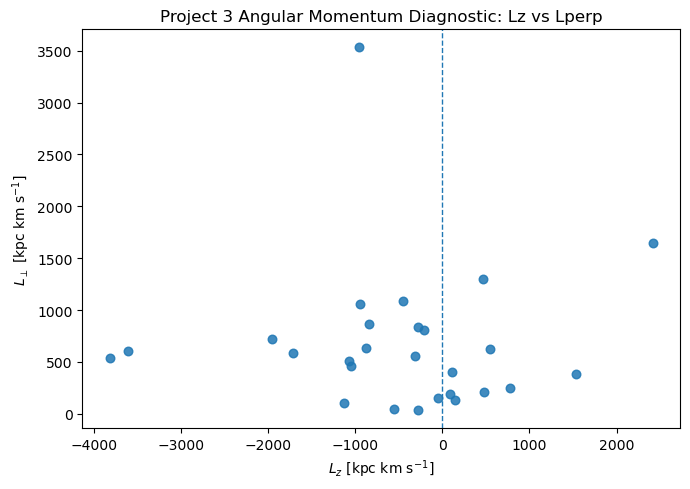

/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/project3_angular_momentum_lz_lperp.png


In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(am["Lz_kpc_kms"], am["Lperp_kpc_kms"], s=38, alpha=0.85)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel(r"$L_z$ [kpc km s$^{-1}$]")
plt.ylabel(r"$L_\perp$ [kpc km s$^{-1}$]")
plt.title("Project 3 Angular Momentum Diagnostic: Lz vs Lperp")
plt.tight_layout()
fig1 = FIG_DIR / "project3_angular_momentum_lz_lperp.png"
plt.savefig(fig1, dpi=220)
plt.show()
print(fig1)


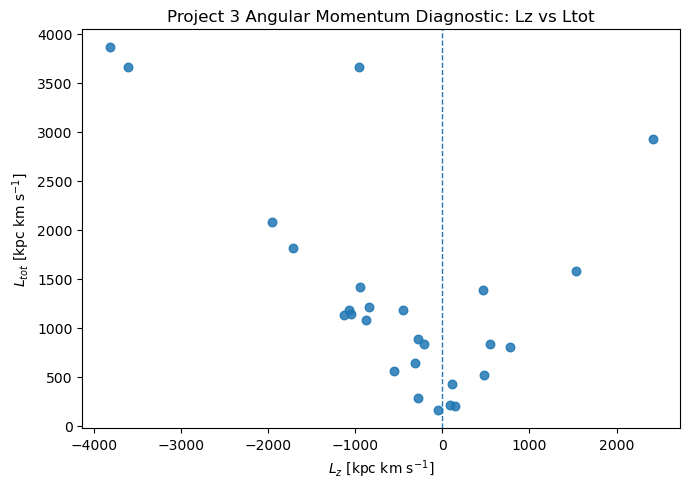

/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/project3_angular_momentum_lz_ltot.png


In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(am["Lz_kpc_kms"], am["Ltot_kpc_kms"], s=38, alpha=0.85)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel(r"$L_z$ [kpc km s$^{-1}$]")
plt.ylabel(r"$L_{tot}$ [kpc km s$^{-1}$]")
plt.title("Project 3 Angular Momentum Diagnostic: Lz vs Ltot")
plt.tight_layout()
fig2 = FIG_DIR / "project3_angular_momentum_lz_ltot.png"
plt.savefig(fig2, dpi=220)
plt.show()
print(fig2)


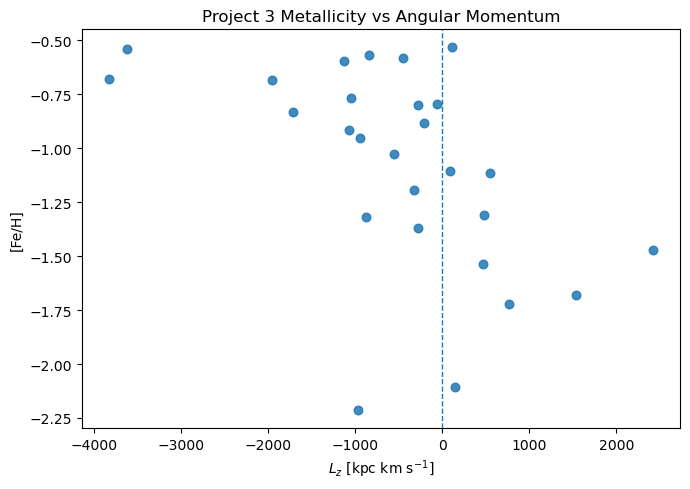

/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/project3_angular_momentum_feh_lz.png


In [9]:
if feh_col is not None:
    plt.figure(figsize=(7, 5))
    plt.scatter(am["Lz_kpc_kms"], pd.to_numeric(am[feh_col], errors="coerce"), s=38, alpha=0.85)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel(r"$L_z$ [kpc km s$^{-1}$]")
    plt.ylabel("[Fe/H]")
    plt.title("Project 3 Metallicity vs Angular Momentum")
    plt.tight_layout()
    fig3 = FIG_DIR / "project3_angular_momentum_feh_lz.png"
    plt.savefig(fig3, dpi=220)
    plt.show()
    print(fig3)
else:
    print("No metallicity column detected; skipping [Fe/H] vs Lz plot.")


## 5. Save outputs

In [10]:
# Save candidate-level angular-momentum table.
am.to_csv(OUTPUT_PATH, index=False)

# Save compact metric summary plus class-count summary in one CSV-friendly table.
summary_out = summary.copy()
summary_out["section"] = "angular_momentum_metrics"

class_out = class_summary.copy()
class_out["metric"] = class_out["rotation_class"] + " / " + class_out["inclination_proxy_class"]
class_out["n"] = class_out["n_candidates"]
class_out["mean"] = np.nan
class_out["median"] = np.nan
class_out["std"] = np.nan
class_out["min"] = np.nan
class_out["max"] = np.nan
class_out["section"] = "classification_counts"
class_out = class_out[summary_out.columns]

combined_summary = pd.concat([summary_out, class_out], ignore_index=True)
combined_summary.to_csv(SUMMARY_PATH, index=False)

print("Saved:", OUTPUT_PATH, am.shape)
print("Saved:", SUMMARY_PATH, combined_summary.shape)
combined_summary


Saved: /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/project3_angular_momentum_candidates.csv (27, 71)
Saved: /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/project3_angular_momentum_summary.csv (12, 8)


,metric,n,mean,median,std,min,max,section
0,Lx_kpc_kms,27,19.472524,-2.393509,227.045258,-603.463640,371.548743,angular_momentum_metrics
1,Ly_kpc_kms,27,-407.185892,-202.852710,856.957365,-3516.979739,832.124391,angular_momentum_metrics
2,Lz_kpc_kms,27,-501.915500,-320.508926,1313.040367,-3824.068568,2417.299615,angular_momentum_metrics
3,Lperp_kpc_kms,27,677.733759,556.687734,693.907203,37.141078,3531.457514,angular_momentum_metrics
4,Ltot_kpc_kms,27,1321.301436,1129.900953,1063.576428,160.597383,3862.109463,angular_momentum_metrics
5,retrograde / low_Lperp,9,NaN,NaN,NaN,NaN,NaN,classification_counts
6,low_Lz_or_radial / low_Lperp,7,NaN,NaN,NaN,NaN,NaN,classification_counts
7,low_Lz_or_radial / moderate_Lperp,4,NaN,NaN,NaN,NaN,NaN,classification_counts
8,prograde / low_Lperp,3,NaN,NaN,NaN,NaN,NaN,classification_counts
9,retrograde / moderate_Lperp,2,NaN,NaN,NaN,NaN,NaN,classification_counts


## 6. Notes for interpretation

- Positive and negative \(L_z\) separate opposite senses of Galactic rotation under the adopted Galactocentric convention.
- Low \(|L_z|\) with substantial \(L_\perp\) can flag radial or high-inclination halo-like behavior.
- The current milestone is diagnostic, not a definitive dynamical classification.
- Later milestones should compare these angular-momentum diagnostics with metallicity, velocity-space evidence, and eventually orbit integration.
